<a href="https://colab.research.google.com/github/AlvinManoj05/-CaseStudy_House_Pricing-/blob/main/House_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,roc_curve,roc_auc_score

In [225]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset Overview**


1. Load the dataset House_Pricing.csv  

2.   Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values.

In [226]:
df = pd.read_csv("/content/drive/MyDrive/AI-ML/Datasets/House_Pricing.csv")

In [227]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [228]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [229]:
df = df.drop('ID', axis = 1)

In [230]:
df.shape

(21613, 20)

In [231]:
df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Date House was Sold                        21613 non-null  object 
 1   Sale Price                                 21609 non-null  float64
 2   No of Bedrooms                             21613 non-null  int64  
 3   No of Bathrooms                            21609 non-null  float64
 4   Flat Area (in Sqft)                        21604 non-null  float64
 5   Lot Area (in Sqft)                         21604 non-null  float64
 6   No of Floors                               21613 non-null  float64
 7   Waterfront View                            21613 non-null  object 
 8   No of Times Visited                        2124 non-null   object 
 9   Condition of the House                     21613 non-null  object 
 10  Overall Grade         

# Duplicate Removal


---


1.   Rows: Check for duplicate rows in the dataset, if any, and remove them.

2.   Columns: Identify and drop duplicate columns, if any, based on their values.





In [233]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [234]:
df = df.drop_duplicates()

In [235]:
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows after removal: 0


# Handling Missing Values

In [236]:
# Checking missing value
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19487
Condition of the House,0


In [237]:
(df.isnull().sum()/len(df))*100

,0
Date House was Sold,0.000000
Sale Price,0.018509
No of Bedrooms,0.000000
No of Bathrooms,0.018509
Flat Area (in Sqft),0.041645
Lot Area (in Sqft),0.041645
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.171672
Condition of the House,0.000000


In [238]:
df.columns[df.T.duplicated()]

Index([], dtype='object')

In [239]:
# Remove *"No of Times Visited"* as it has more than 90% null values

df = df.drop('No of Times Visited', axis=1)

In [240]:
 df.dtypes

,0
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
Condition of the House,object
Overall Grade,int64


In [241]:
numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_columns = df.select_dtypes(
    include=['object']
).columns


# Numerical columns - median
for col in numerical_columns:

    if col != "Sale Price":
        df[col] = df[col].fillna(df[col].median())

In [242]:
# Categorical columns - mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [243]:
# Target variable - remove missing rows
df = df.dropna(subset=["Sale Price"])

# Imputers

In [244]:
#imputers
from sklearn.impute import KNNImputer,SimpleImputer

In [245]:
# Simple Imputer
simple_imputer=SimpleImputer(strategy="most_frequent")

In [246]:
df_cat=df.select_dtypes(include="object")

df_cat_impute=pd.DataFrame(simple_imputer.fit_transform(df_cat),columns=df_cat.columns,index=df_cat.index )

In [247]:
df_cat_impute.isna().sum()

,0
Date House was Sold,0
Waterfront View,0
Condition of the House,0


### KNNImputer-For Numerical Values

In [248]:
KNN_imputer=KNNImputer()

In [249]:
df_num=df.select_dtypes(exclude="object")

In [250]:
df_num_impute=pd.DataFrame(KNN_imputer.fit_transform(df_num),columns=df_num.columns,index=df_num.index)

In [251]:
df_num_impute.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


In [252]:
df_imputed = pd.concat([df_cat_impute,df_num_impute], axis = 1)

In [253]:
print(df_imputed.columns)

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House',
       'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [254]:
df.columns = df.columns.str.strip()

In [255]:
print(df.columns)

Index(['Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'Condition of the House',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [256]:
print(df.columns)

Index(['Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'Condition of the House',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


Encoding Categorical Variables




In [257]:
df_imputed.dtypes

,0
Date House was Sold,object
Waterfront View,object
Condition of the House,object
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Overall Grade,float64


## *Label Encoder*

In [258]:
lb=LabelEncoder()

cols_encode=["Condition of the House","Waterfront View"]

In [259]:
for col in cols_encode:
  df_imputed[col]=lb.fit_transform(df[col])
df_imputed.dtypes

,0
Date House was Sold,object
Waterfront View,int64
Condition of the House,int64
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Overall Grade,float64


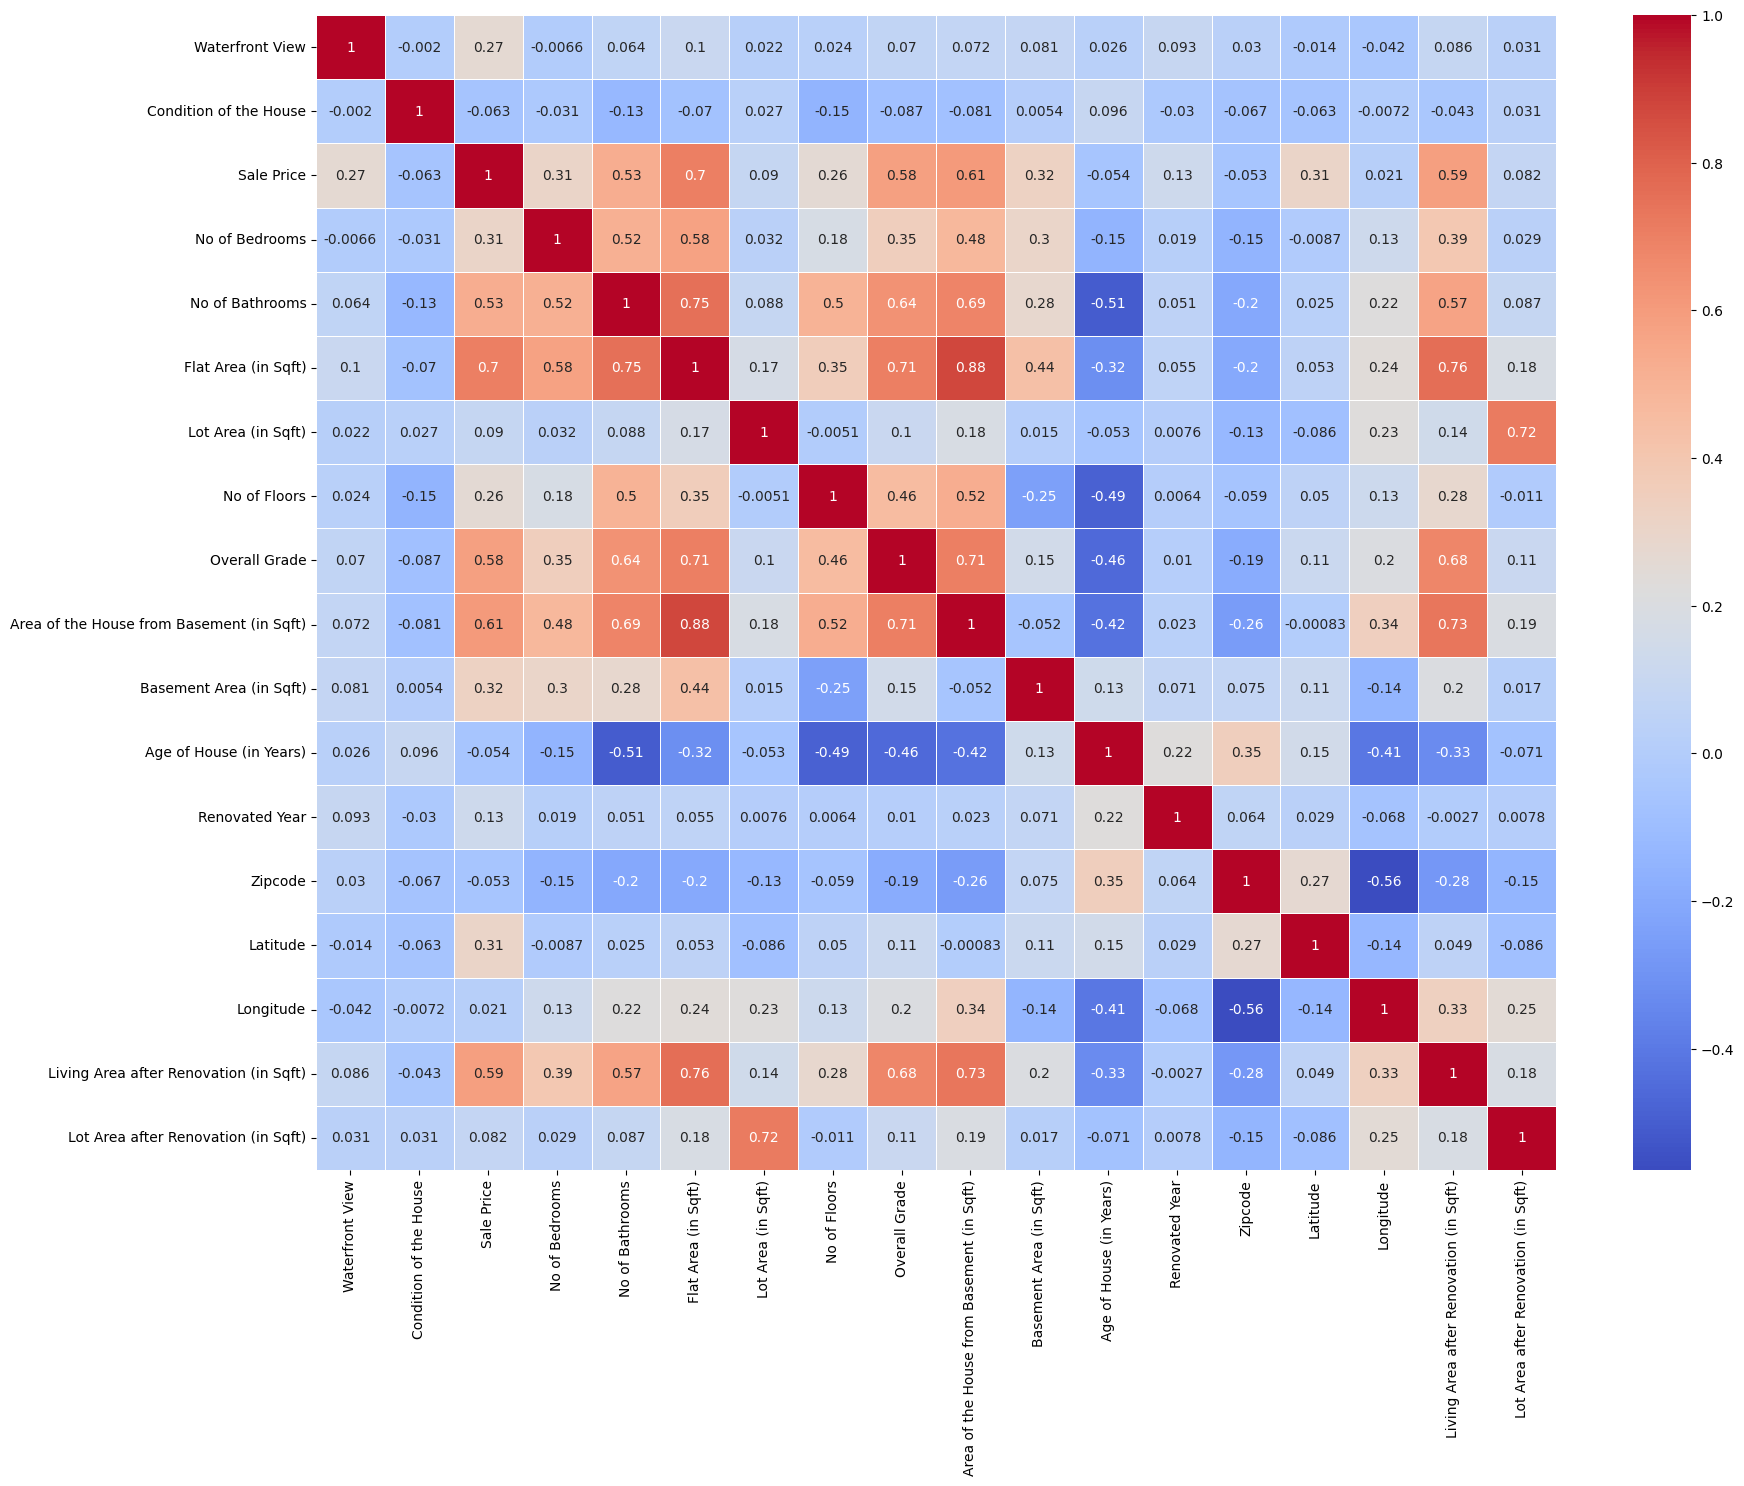

In [260]:
corr_result = df_imputed.select_dtypes(include='number').corr()

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_result,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)
plt.show()

In [261]:
#My target is Saleprice
#My absolute value is .7
corr_columns=["Flat Area (in Sqft)","Living Area after Renovation (in Sqft)","Area of the House from Basement (in Sqft)","Sale Price"]

In [262]:
#Remove other
df_imputed.drop(columns=df_imputed.columns.difference(corr_columns),inplace=True)

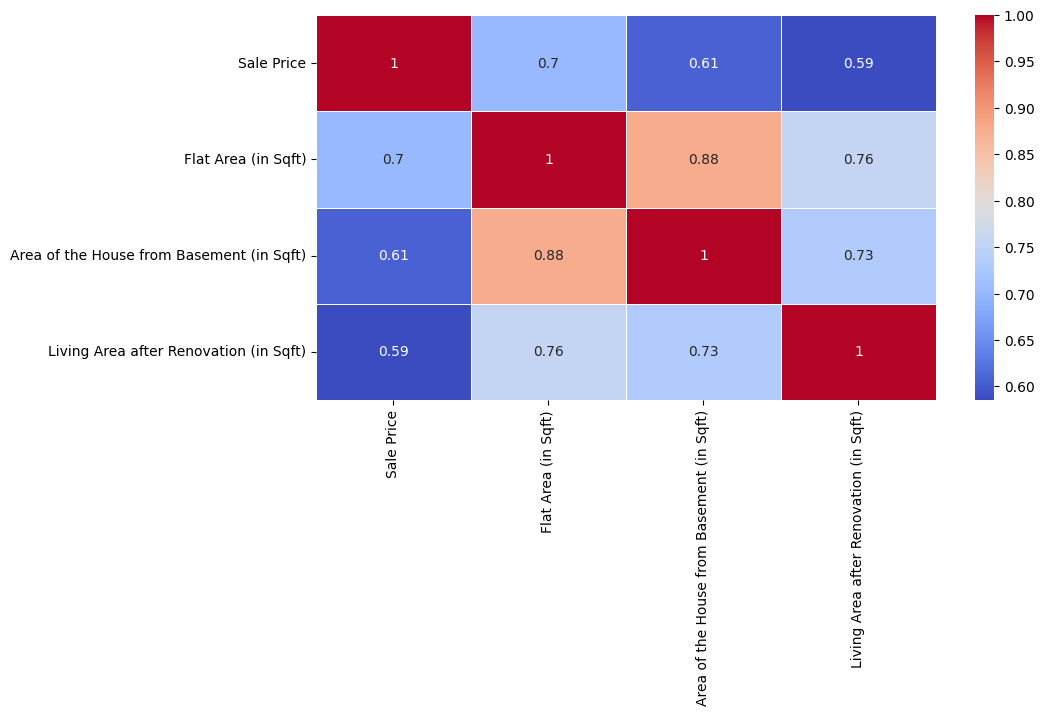

In [263]:
corr_result=df_imputed.corr()
plt.figure(figsize=(10,5))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5)
plt.show()

# Checking Outliers

In [264]:
# *Outlier Removal*

plt.figure(figsize=(8,5))
columns=df_imputed.columns

<Figure size 800x500 with 0 Axes>

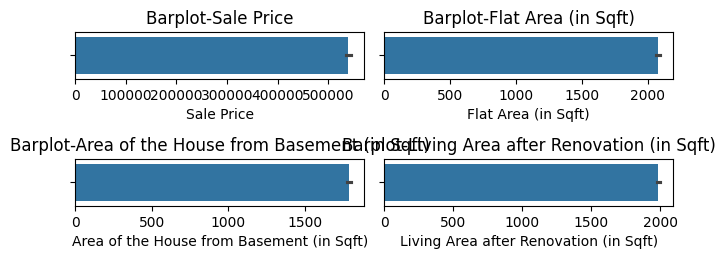

In [265]:
for i,col in enumerate(columns):
  plt.subplot(len(columns),2,i+1)
  sns.barplot(x=df[col])
  plt.title(f"Barplot-{col}")
plt.tight_layout()
plt.show()

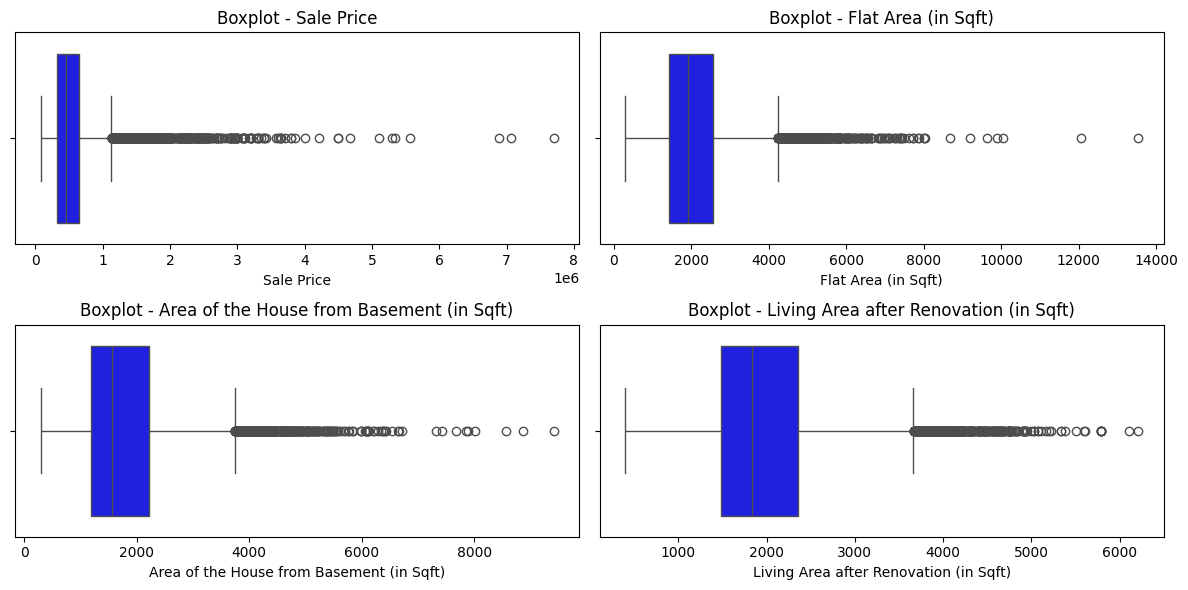

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Scale figure size dynamically based on the number of rows
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Use boxplot to highlight outliers (represented as individual dots)
    sns.boxplot(x=df_imputed[col], color='blue')
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()







In [267]:
## **Fixing Outliers**

df_imputed.columns


#fixing the outliers

cols_with_outliers=['Sale Price', 'Flat Area (in Sqft)',
       'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)']

def fixCols():
  for col in cols_with_outliers:
    Q1=df_imputed[col].quantile(.25)
    Q3=df_imputed[col].quantile(.75)

    IQR=Q3-Q1

    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR

    initial_outlier=df_imputed[(df_imputed[col]<lower_bound)|(df_imputed[col]>upper_bound)]

    print(f"Outliers in {col} before treatment:",initial_outlier[col].count())
    print("Treating Outliers...")
    df_imputed[col]=df_imputed[col].clip(upper=upper_bound,lower=lower_bound)
    final_outlier=df_imputed[(df_imputed[col]<lower_bound)|(df_imputed[col]>upper_bound)]
    print(f"Outliers in {col} after treatment:",final_outlier[col].count())

fixCols()

Outliers in Sale Price before treatment: 1159
Treating Outliers...
Outliers in Sale Price after treatment: 0
Outliers in Flat Area (in Sqft) before treatment: 572
Treating Outliers...
Outliers in Flat Area (in Sqft) after treatment: 0
Outliers in Area of the House from Basement (in Sqft) before treatment: 610
Treating Outliers...
Outliers in Area of the House from Basement (in Sqft) after treatment: 0
Outliers in Living Area after Renovation (in Sqft) before treatment: 544
Treating Outliers...
Outliers in Living Area after Renovation (in Sqft) after treatment: 0


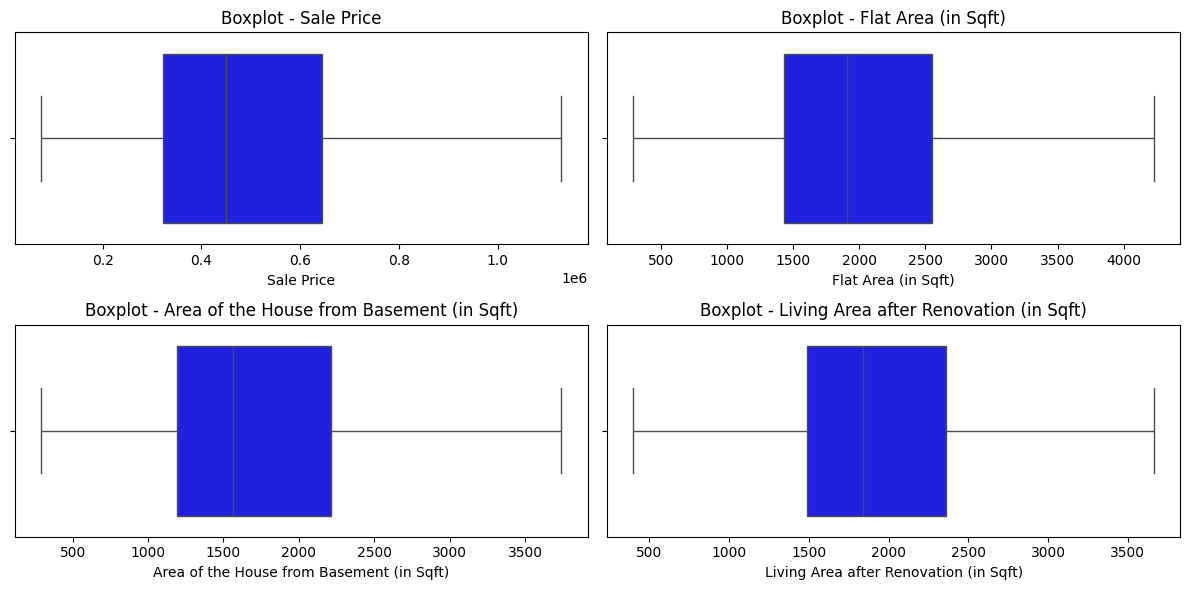

In [268]:

import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Scale figure size dynamically based on the number of rows
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Use boxplot to highlight outliers (represented as individual dots)
    sns.boxplot(x=df_imputed[col], color='blue')
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

# Train-Test Split

In [269]:
X=df[['Flat Area (in Sqft)','Overall Grade','Area of the House from Basement (in Sqft)']]
y=df["Sale Price"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Scaling Numerical Variables

In [270]:
scaler=StandardScaler()

In [271]:
X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.fit(X_test)

In [272]:
columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)
